In [2]:
# ----- Back-Propagation Through Time (BPTT) ------

In [3]:
# Data synthesis
import numpy as np

L = 10 # length of x sequences

x=[]
for t in range(L):
    if np.random.rand() > 0.4: #60% of "1" and 40% of "o"
        x.append(1.)
    else:
        x.append(0.)

y_true=[0., 0.] #y_true[0] = 0., y_true[1] = 0.
for i in range(L-1):
    y_true.append(x[i]*x[i+1]) #y_true[2] = x[0] & x[1], y_true[3] = x[1] & x[2]
print('x:', x)
print('y:', y_true)

for t in range(L-1):
    print(x[t], '*', x[t+1], '=', y_true[t+2])

x: [1.0, 1.0, 0.0, 0.0, 1.0, 0.0, 0.0, 1.0, 1.0, 0.0]
y: [0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0]
1.0 * 1.0 = 1.0
1.0 * 0.0 = 0.0
0.0 * 0.0 = 0.0
0.0 * 1.0 = 0.0
1.0 * 0.0 = 0.0
0.0 * 0.0 = 0.0
0.0 * 1.0 = 0.0
1.0 * 1.0 = 1.0
1.0 * 0.0 = 0.0


In [4]:
# learning
alpha = 1. #Learning rate
w1 = 0.1; w2 = -0.; b = -0. #Random inititial parameters

for epoch in range(10000):
    
    y = [0.]; dydb = [0.]; dydw1 = [0.]; dydw2 = [0.]
    
    for t in range(L):
        
        s = w1*x[t] + w2*y[t] + b # weighted sum
        next_y = 1./(1.+np.exp(-s)) # next output

        next_dydb = next_y*(1.-next_y)*(1. + w2*dydb[t]) # calculate derivatives; next_dydb = dyds * dsdb
        next_dydw1 = next_y*(1.-next_y)*(x[t] + w2*dydw1[t]) # next_dydw1 = dyds * dsdw1
        next_dydw2 = next_y*(1.-next_y)*(y[t] + w2*dydw2[t]) # next_dydw2 = dyds * dsdw2
        
        # save current state
        y.append(next_y)
        dydb.append(next_dydb)
        dydw1.append(next_dydw1)
        dydw2.append(next_dydw2)

    dEdb = 0.; dEdw1 = 0.; dEdw2 = 0.;
    
    for t in range(3,L):
        
        dEdb += (y[t]-y_true[t])*dydb[t] # dEdb = dEdy * dydb
        dEdw1 += (y[t]-y_true[t])*dydw1[t] # dEdb = dEdy * dydw1
        dEdw2 += (y[t]-y_true[t])*dydw2[t] # dEdb = dEdy * dydw2

    # parameter update
    b = b - alpha*dEdb
    w1 = w1 - alpha*dEdw1
    w2 = w2 - alpha*dEdw2

    # check training
    if epoch % 1000 == 0:
        dy = np.array(y) - np.array(y_true)
        print('epoch',epoch,'-->', 'cost', np.dot(dy, dy)/2)

epoch 0 --> cost 1.2640494932572401
epoch 1000 --> cost 0.16355960799038338
epoch 2000 --> cost 0.12225875971132133
epoch 3000 --> cost 0.10279094766035243
epoch 4000 --> cost 0.0907871542120702
epoch 5000 --> cost 0.08240874474326904
epoch 6000 --> cost 0.07611973809900884
epoch 7000 --> cost 0.07116676522616691
epoch 8000 --> cost 0.06713039417343977
epoch 9000 --> cost 0.06375577654396997


In [5]:
# Validation of training data
for t in range(L-1):
    print('{0:} * {1:} = {2:3.2f} (y_true = {3:})'.format(x[t], x[t+1], y[t+2], y_true[t+2]))

1.0 * 1.0 = 0.87 (y_true = 1.0)
1.0 * 0.0 = 0.04 (y_true = 0.0)
0.0 * 0.0 = 0.00 (y_true = 0.0)
0.0 * 1.0 = 0.17 (y_true = 0.0)
1.0 * 0.0 = 0.00 (y_true = 0.0)
0.0 * 0.0 = 0.00 (y_true = 0.0)
0.0 * 1.0 = 0.17 (y_true = 0.0)
1.0 * 1.0 = 0.87 (y_true = 1.0)
1.0 * 0.0 = 0.04 (y_true = 0.0)


In [6]:
print('w1 = {0:3.1f}, w2 = {1:3.1f}, b = {2:3.1f}'.format(w1, w2, b))

w1 = 19.7, w2 = 20.9, b = -21.3


In [9]:
# Prediction for new questions
from sklearn.utils import shuffle
x = 10*[0.] + 15*[1.]
x = shuffle(x)

y_true=[0., 0.] #y_true[0] = 0., y_true[1] = 0.
for i in range(len(x)-1):
    y_true.append(x[i]*x[i+1]) #y_true[2] = x[0] & x[1], y_true[3] = x[1] & x[2]

y = [0.]
for t in range(len(x)):
    s = w1*x[t] + w2*y[t] + b # 앞에서 구한 파라미터값을 그대로 씀
    next_y = 1./(1.+np.exp(-s))
    y.append(next_y)

for t in range(len(x)-1):
    print('{0:} * {1:} = {2:3.2f} (y_true = {3:})'.format(x[t], x[t+1], y[t+2], y_true[t+2]))

0.0 * 0.0 = 0.00 (y_true = 0.0)
0.0 * 1.0 = 0.17 (y_true = 0.0)
1.0 * 1.0 = 0.87 (y_true = 1.0)
1.0 * 0.0 = 0.04 (y_true = 0.0)
0.0 * 0.0 = 0.00 (y_true = 0.0)
0.0 * 0.0 = 0.00 (y_true = 0.0)
0.0 * 0.0 = 0.00 (y_true = 0.0)
0.0 * 1.0 = 0.17 (y_true = 0.0)
1.0 * 0.0 = 0.00 (y_true = 0.0)
0.0 * 1.0 = 0.17 (y_true = 0.0)
1.0 * 1.0 = 0.87 (y_true = 1.0)
1.0 * 1.0 = 1.00 (y_true = 1.0)
1.0 * 1.0 = 1.00 (y_true = 1.0)
1.0 * 1.0 = 1.00 (y_true = 1.0)
1.0 * 1.0 = 1.00 (y_true = 1.0)
1.0 * 0.0 = 0.40 (y_true = 0.0)
0.0 * 1.0 = 1.00 (y_true = 0.0)
1.0 * 0.0 = 0.40 (y_true = 0.0)
0.0 * 1.0 = 1.00 (y_true = 0.0)
1.0 * 1.0 = 1.00 (y_true = 1.0)
1.0 * 0.0 = 0.40 (y_true = 0.0)
0.0 * 1.0 = 1.00 (y_true = 0.0)
1.0 * 1.0 = 1.00 (y_true = 1.0)
1.0 * 1.0 = 1.00 (y_true = 1.0)


In [10]:
# ----- Real-Time Recurrent Lenarning (RTRL) ------

In [1]:
alpha = 1.; #Learning rate

w1 = 0.; w2 = -0.; b = -0. #Random inititial parameters
prev_x = 0.; x = 0.; y = 0. # 변수가 계속 업데이트 되므로 array로 지정할 필요 없음

y_true = 0.
dydb = 0.; dydw1 = 0.; dydw2 = 0.

for epoch in range(100000):
    
    s = x*w1 + y*w2 + b # weighted sum
    next_y = 1./(1. + np.exp(-s)) # next output
    
    next_dydb = next_y*(1. - next_y)*(1. + w2*dydb) # calculate derivatives
    next_dydw1 = next_y*(1. - next_y)*(x + w2*dydw1)
    next_dydw2 = next_y*(1. - next_y)*(y+w2*dydw2)

    # parameter update
    b = b - alpha*(next_y - y_true)*next_dydb
    w1 = w1 - alpha*(next_y - y_true)*next_dydw1
    w2 = w2 - alpha*(next_y - y_true)*next_dydw2

    # set next y_true
    if np.random.rand() > 0.4:
        next_x=1.
    else:
        next_x=0.
    next_y_true=(x*next_x)

    # check training
    if epoch % 1000 == 0:
        print('{0:.1f}*{1:.1f} = {2:.2f} (true y: {3:.2f})'.format(prev_x, x, next_y, y_true))

    # save current state
    prev_x = x
    x = next_x
    y = next_y
    dydb = next_dydb
    dydw1 = next_dydw1
    dydw2 = next_dydw2
    y_true = next_y_true

0.0*0.0 = 0.50 (true y: 0.00)
0.0*0.0 = 0.01 (true y: 0.00)
1.0*1.0 = 0.98 (true y: 1.00)
0.0*0.0 = 0.00 (true y: 0.00)
1.0*0.0 = 0.01 (true y: 0.00)
1.0*0.0 = 0.05 (true y: 0.00)
1.0*0.0 = 0.00 (true y: 0.00)
1.0*0.0 = 0.01 (true y: 0.00)
0.0*0.0 = 0.00 (true y: 0.00)
1.0*1.0 = 0.80 (true y: 1.00)
1.0*1.0 = 0.71 (true y: 1.00)
1.0*0.0 = 0.03 (true y: 0.00)
0.0*0.0 = 0.00 (true y: 0.00)
1.0*1.0 = 0.83 (true y: 1.00)
1.0*1.0 = 1.00 (true y: 1.00)
0.0*1.0 = 0.23 (true y: 0.00)
0.0*0.0 = 0.00 (true y: 0.00)
0.0*0.0 = 0.00 (true y: 0.00)
0.0*0.0 = 0.00 (true y: 0.00)
0.0*0.0 = 0.00 (true y: 0.00)
0.0*0.0 = 0.00 (true y: 0.00)
0.0*1.0 = 0.20 (true y: 0.00)
1.0*1.0 = 1.00 (true y: 1.00)
0.0*0.0 = 0.00 (true y: 0.00)
0.0*1.0 = 0.24 (true y: 0.00)
1.0*1.0 = 0.87 (true y: 1.00)
0.0*0.0 = 0.00 (true y: 0.00)
0.0*0.0 = 0.00 (true y: 0.00)
0.0*0.0 = 0.00 (true y: 0.00)
1.0*1.0 = 1.00 (true y: 1.00)
0.0*0.0 = 0.00 (true y: 0.00)
1.0*0.0 = 0.01 (true y: 0.00)
1.0*0.0 = 0.00 (true y: 0.00)
1.0*1.0 = 

In [11]:
print('w1 = {0:3.1f}, w2 = {1:3.1f}, b = {2:3.1f}'.format(w1, w2, b))

w1 = 19.7, w2 = 20.9, b = -21.3


t =   500 | predicted = 0.73 | actual = 0.74
t =  1000 | predicted = 0.90 | actual = 0.92
t =  1500 | predicted = 0.97 | actual = 1.00
t =  2000 | predicted = 0.98 | actual = 0.95
t =  2500 | predicted = 0.81 | actual = 0.80
t =  3000 | predicted = 0.58 | actual = 0.57
t =  3500 | predicted = 0.33 | actual = 0.32
t =  4000 | predicted = 0.14 | actual = 0.12
t =  4500 | predicted = 0.05 | actual = 0.01
t =  5000 | predicted = 0.03 | actual = 0.02
t =  5500 | predicted = 0.06 | actual = 0.15
t =  6000 | predicted = 0.35 | actual = 0.36
t =  6500 | predicted = 0.60 | actual = 0.61
t =  7000 | predicted = 0.82 | actual = 0.83
t =  7500 | predicted = 0.94 | actual = 0.97
t =  8000 | predicted = 0.98 | actual = 0.99
t =  8500 | predicted = 0.96 | actual = 0.90
t =  9000 | predicted = 0.71 | actual = 0.71
t =  9500 | predicted = 0.47 | actual = 0.46
t = 10000 | predicted = 0.24 | actual = 0.23
t = 10500 | predicted = 0.09 | actual = 0.06
t = 11000 | predicted = 0.04 | actual = 0.00
t = 11500 

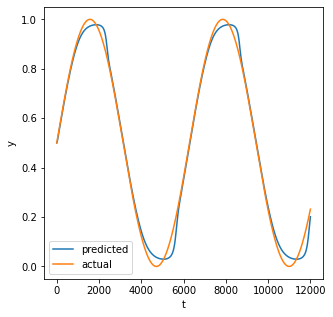

In [13]:
# 예시
import matplotlib.pyplot as plt
    
alpha = 1.

y = 0. ; y_true = 0.5 ; ys=[0.5]

dydb = 0.; dydw1 = 0.

w = 0.; b = 0.


for i in range(1,12001):
    # weighted sum
    s = w * y + b
    
    # next output
    next_y = 1./(1. + np.exp(-s))
    
    # save output
    ys.append(next_y)
    
    # calculate derivatives
    next_dydb = next_y*(1.-next_y)*1.
    next_dydw = next_y*(1.-next_y)*y
    
    # parameter update
    b = b - alpha*(next_y - y_true)*next_dydb
    w = w - alpha*(next_y - y_true)*next_dydw
    
    # set next y_true
    next_y_true = (np.sin(0.001*i)+1)/2
    
    # save current state
    y = next_y
    dydb = next_dydb
    dydw = next_dydw
    y_true = next_y_true
    
    # check training
    if i%500 == 0:
        print("t = {:5d} | predicted = {:.2f} | actual = {:.2f}".format(i,next_y,y_true))
    
# print final parameters
print("\nFinal parameters: w = {:.2f}, b = {:.2f}\n".format(w,b))

# plot
true_y = [(np.sin(0.001*x)+1)/2 for x in range(len(ys))]
plt.figure(figsize=(5,5))
plt.plot(list(range(len(ys))), ys, label="predicted")
plt.plot(list(range(len(true_y))), true_y, label="actual")
plt.xlabel('t')
plt.ylabel('y')
plt.legend()
plt.show()